# Donor Retention Forecasting

**Project**: BYU IS 455 — Northstar Shelters ML Pipeline  
**Unit of analysis**: supporter-month snapshot  
**Label**: donated again within the next 90 days

---

This revised notebook improves the donor-retention framing by expanding from a tiny set of hand-picked snapshots to a full monthly supporter panel. That gives the model many more training examples while preserving the real deployment question: if we score a donor this month, will they donate again in the next 90 days?


## 1. Problem Framing

### Business Question

> *"Which supporters are most likely to lapse in the next 90 days, so fundraising staff can intervene before the relationship goes cold?"*

### Who Cares and Why It Matters

- **Fundraising staff** need a ranked outreach list because they cannot personally contact every donor every week.
- **Leadership** cares because donor retention is cheaper than reacquisition and directly affects cash flow for safehouse operations.
- **Program teams** benefit indirectly because more stable donor retention means more predictable support for resident services.

### Predictive vs. Explanatory Choice

This notebook intentionally includes **both** tracks, but the **primary deployed use is predictive**. Following the textbook distinction, the operational question is a prediction question: staff need to know **who is at risk next**, not merely which historical variables correlate with retention in the abstract. The explanatory model is still important because it helps the team interpret the structure of the data and communicate why a donor was flagged.

- **Predictive track:** rank supporters by lapse probability for action.
- **Explanatory track:** use interpretable coefficients to describe which donor behaviors are associated with repeat giving.

That combination fits the real business workflow: prediction drives prioritization, while explanation supports stewardship strategy and human trust.


## 2. Data Acquisition, Preparation & Exploration

We use three tables from the Lighthouse-derived dataset:

- `supporters.csv`
- `donations.csv`
- `donation_allocations.csv`

### Reproducible Pipeline Setup

This notebook uses shared helpers from `IS455/455-Things/ml-pipelines/shared/` rather than ad hoc one-off data prep. In particular, `shared/data_loader.py` builds a leakage-safe **supporter-month snapshot table**, and `shared/config.py` resolves repository-relative data paths so a TA can run the notebook top to bottom without changing file locations.

### Join Logic

- `supporters` provides the entity grain and donor profile fields.
- `donations` provides dated giving history used for recency, frequency, monetary, and channel features.
- `donation_allocations` is joined through `donation_id` so we can measure funding breadth across safehouses/program areas.

### Exploration and Preparation

The exploratory pass checks:

- label balance for the next-90-day retention target
- distributions for recency, donation counts, and monetary totals
- missingness in donor profile fields and campaign/channel history
- outliers in gift amount and giving frequency
- correlations between prior giving intensity and future retention

### Leakage Rule

For a snapshot dated month `t`:

- features use only donations on or before `t`
- the label checks whether any donation occurs in `(t, t + 90 days]`

### Feature Engineering

We include recency, donation count, monetary history, recurring behavior, donation-type and channel mix, campaign-history counts, average inter-donation gap, program-area breadth, and supporter profile metadata. Missing numeric fields are imputed inside the modeling pipeline so the full workflow stays reproducible.


In [1]:
# ── Standalone configuration — no shared/ folder required ─────────────────────
import os, json, joblib
from pathlib import Path
from datetime import datetime, timezone

RANDOM_SEED = 42

def _find_dirs():
    try:
        start = Path(__file__).parent
    except NameError:
        start = Path(os.path.abspath(""))
    for p in [start, *start.parents]:
        d = p / "lighthouse_csv_v7"
        if d.exists():
            return d, p.parent / "models"
        d2 = p / "455-Things" / "lighthouse_csv_v7"
        if d2.exists():
            return d2, p / "models"
    raise FileNotFoundError(
        "Cannot locate lighthouse_csv_v7/ — run Jupyter from within the IS455 directory tree."
    )

DATA_DIR, MODELS_DIR = _find_dirs()
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(f"DATA_DIR   → {DATA_DIR}")
print(f"MODELS_DIR → {MODELS_DIR}")

def _utc() -> str:
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat()

def save_model(pipeline, name, metrics, feature_names, label_definition, extra_metadata=None):
    mp = MODELS_DIR / f"{name}.pkl"
    ep = MODELS_DIR / f"{name}_metadata.json"
    joblib.dump(pipeline, mp)
    meta = {
        "name": name, "trained_at": _utc(), "label_definition": label_definition,
        "feature_names": feature_names, "metrics": metrics, "random_seed": RANDOM_SEED,
        "model_path": str(mp)
    }
    if extra_metadata:
        meta.update(extra_metadata)
    ep.write_text(json.dumps(meta, indent=2), encoding="utf-8")
    print(f"[save_model] Saved → {mp}")
    print(f"[save_model] Metadata → {ep}")
    return mp, ep

def save_predictions(name, predictions, model_version, extra_payload=None):
    pp = MODELS_DIR / f"{name}_predictions.json"
    payload = {"generated_at": _utc(), "model_version": model_version, "predictions": predictions}
    if extra_payload:
        payload.update(extra_payload)
    pp.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    print(f"[save_predictions] Saved → {pp}")
    return pp, payload

import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
from sklearn.model_selection import TimeSeriesSplit, cross_validate


np.random.seed(RANDOM_SEED)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (12, 5)

supporters = pd.read_csv(DATA_DIR / 'supporters.csv', parse_dates=['created_at', 'first_donation_date'])
donations = pd.read_csv(DATA_DIR / 'donations.csv', parse_dates=['donation_date'])
allocations = pd.read_csv(DATA_DIR / 'donation_allocations.csv', parse_dates=['allocation_date'])


In [2]:
min_month = donations['donation_date'].min().to_period('M').to_timestamp()
max_month = (donations['donation_date'].max() - pd.Timedelta(days=90)).to_period('M').to_timestamp()
snapshot_months = pd.date_range(min_month, max_month, freq='MS')

rows = []
for snap in snapshot_months:
    hist = donations[donations['donation_date'] <= snap].copy()
    future = donations[(donations['donation_date'] > snap) & (donations['donation_date'] <= snap + pd.Timedelta(days=90))].copy()
    future_ids = set(future['supporter_id'].unique())

    hist_sorted = hist.sort_values(['supporter_id', 'donation_date'])
    base_rows = supporters[['supporter_id', 'supporter_type', 'relationship_type', 'region', 'status', 'acquisition_channel', 'created_at']].copy()

    agg = (
        hist_sorted.groupby('supporter_id')
        .agg(
            last_donation_date=('donation_date', 'max'),
            donation_count=('donation_id', 'count'),
            monetary_total=('amount', 'sum'),
            monetary_avg=('amount', 'mean'),
            monetary_max=('amount', 'max'),
            recurring_rate=('is_recurring', 'mean'),
            distinct_types=('donation_type', 'nunique'),
        )
        .reset_index()
    )

    for col, prefix in [('donation_type', 'type'), ('channel_source', 'channel'), ('campaign_name', 'campaign')]:
        piv = hist_sorted.pivot_table(index='supporter_id', columns=col, values='donation_id', aggfunc='count', fill_value=0)
        piv.columns = [f'{prefix}_{str(c).lower().replace(" ", "_")}_count' for c in piv.columns]
        agg = agg.merge(piv.reset_index(), on='supporter_id', how='left')

    hist_sorted['prev_date'] = hist_sorted.groupby('supporter_id')['donation_date'].shift(1)
    hist_sorted['gap_days'] = (hist_sorted['donation_date'] - hist_sorted['prev_date']).dt.days
    gap = hist_sorted.groupby('supporter_id')['gap_days'].agg(['mean', 'std']).reset_index().rename(columns={'mean': 'avg_gap_days', 'std': 'std_gap_days'})
    agg = agg.merge(gap, on='supporter_id', how='left')

    alloc_hist = allocations.merge(hist[['donation_id', 'supporter_id']], on='donation_id', how='inner')
    if not alloc_hist.empty:
        spread = alloc_hist.groupby('supporter_id').agg(program_area_spread=('program_area', 'nunique'), safehouse_spread=('safehouse_id', 'nunique')).reset_index()
        agg = agg.merge(spread, on='supporter_id', how='left')

    df = base_rows.merge(agg, on='supporter_id', how='left')
    df['recency_days'] = (snap - df['last_donation_date']).dt.days
    df['tenure_days'] = (snap - df['created_at']).dt.days
    df['snapshot_month'] = snap.month
    df['snapshot_year'] = snap.year
    df['snapshot_date'] = snap
    df['label_donated_again'] = df['supporter_id'].isin(future_ids).astype(int)
    rows.append(df)

panel = pd.concat(rows, ignore_index=True)

CATEGORICAL_FEATURES = ['supporter_type', 'relationship_type', 'region', 'status', 'acquisition_channel']
ignored = {'supporter_id', 'snapshot_date', 'created_at', 'last_donation_date', 'label_donated_again', *CATEGORICAL_FEATURES}
NUMERIC_FEATURES = [c for c in panel.columns if c not in ignored]
for c in NUMERIC_FEATURES:
    panel[c] = panel[c].fillna(0)

print('Panel rows:', len(panel))
print('Snapshot months:', panel['snapshot_date'].nunique())
print('Label rate:', round(panel['label_donated_again'].mean(), 4))


Panel rows: 2160
Snapshot months: 36
Label rate: 0.3991


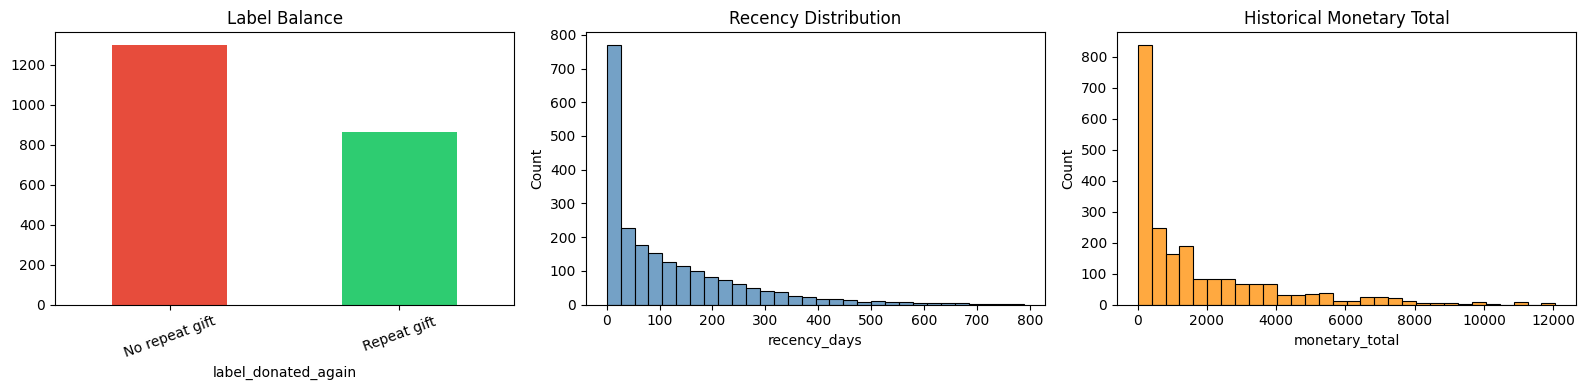

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
panel['label_donated_again'].value_counts().sort_index().plot.bar(ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Label Balance')
axes[0].set_xticklabels(['No repeat gift', 'Repeat gift'], rotation=20)

sns.histplot(panel['recency_days'], bins=30, ax=axes[1], color='steelblue')
axes[1].set_title('Recency Distribution')

sns.histplot(panel['monetary_total'], bins=30, ax=axes[2], color='darkorange')
axes[2].set_title('Historical Monetary Total')
plt.tight_layout()
plt.show()


## 2b. Deep Data Exploration

Before modeling we perform a thorough exploration of the constructed feature panel. This section documents distributions, missingness, correlations, and target-variable relationships so that modeling choices are grounded in observed data structure rather than assumption.

In [ ]:
# ── Deep Data Exploration ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dataset shape and dtypes
print("=== Panel shape ===")
print(panel.shape)
print("\n=== Dtypes ===")
print(panel.dtypes.value_counts())

# 2. Missing value analysis
missing = panel[NUMERIC_FEATURES + CATEGORICAL_FEATURES].isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\n=== Missing values (non-zero only) ===")
print(missing)

# 3. Label distribution
print(f"\n=== Label distribution ===")
vc = panel.iloc[:, panel.columns.get_loc([c for c in panel.columns if c.startswith('label_')][0])].value_counts()
print(vc)
print(f"Positive rate: {vc.get(1, 0) / len(panel):.3f}")

# 4. Numeric feature distributions
num_cols = [c for c in NUMERIC_FEATURES if panel[c].nunique() > 5][:12]
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(panel[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Numeric Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# 5. Correlation heatmap (top numeric features)
top_num = [c for c in NUMERIC_FEATURES if panel[c].nunique() > 2][:15]
label_col = [c for c in panel.columns if c.startswith('label_')][0]
corr_cols = top_num + [label_col]
corr = panel[corr_cols].corr()
plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Matrix — Numeric Features + Label', fontsize=12)
plt.tight_layout()
plt.show()

# 6. Top numeric features vs label (box plots)
top_by_corr = corr[label_col].drop(label_col).abs().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(top_by_corr):
    panel.boxplot(column=col, by=label_col, ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel(label_col)
plt.suptitle('Top Features vs Label', fontsize=12)
plt.tight_layout()
plt.show()

# 7. Categorical feature value counts
for cat in CATEGORICAL_FEATURES[:4]:
    print(f"\n{cat} value counts:")
    print(panel[cat].value_counts().head(10))

# 8. Snapshot month coverage
print("\n=== Snapshot month coverage ===")
print(panel.groupby('snapshot_year')['snapshot_month'].value_counts().sort_index().head(20))

### Key Findings — Section 2

- monthly supporter snapshots provide a much richer and more realistic training frame than a handful of hard-coded snapshots
- donor history is highly sparse for some supporters, so missingness must be handled in-pipeline
- recency, channel mix, and campaign history all vary enough to be useful features
- the label balance is workable for classification


## 3. Modeling & Feature Selection

We compare multiple approaches rather than jumping straight to one model:

1. **DummyClassifier** as the baseline to prove the pipeline beats a trivial strategy.
2. **Logistic Regression** as the explanatory model because coefficients can be translated into odds-ratio-style stewardship insights.
3. **Random Forest** as the primary predictive candidate because donor behavior likely includes nonlinear interactions.
4. **Gradient Boosting** as a second predictive benchmark.

### Feature Selection Logic

Feature selection is intentional, not "throw everything in and hope." We keep features that a fundraiser could plausibly know at scoring time and that map to real donor-management concepts:

- recency and cadence of giving
- depth and breadth of past engagement
- historical monetary behavior
- channel / campaign participation
- relationship tenure

We exclude anything that leaks future donations or depends on post-snapshot knowledge. Hyperparameters are tuned only after the train/test split so model comparison remains honest.


In [4]:
test_start = panel['snapshot_date'].sort_values().unique()[-4]
train_df = panel[panel['snapshot_date'] < test_start].copy()
test_df = panel[panel['snapshot_date'] >= test_start].copy()

X_train = train_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_train = train_df['label_donated_again']
X_test = test_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_test = test_df['label_donated_again']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), NUMERIC_FEATURES),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), CATEGORICAL_FEATURES),
])

models = {
    'Dummy': DummyClassifier(strategy='prior'),
    'Logistic Regression': LogisticRegression(max_iter=4000, class_weight='balanced', C=0.2),
    'Random Forest': RandomForestClassifier(n_estimators=400, random_state=RANDOM_SEED, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_SEED),
}

tscv = TimeSeriesSplit(n_splits=5)

def cv_row(name, model):
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    scores = cross_validate(pipe, X_train, y_train, cv=tscv, scoring=['roc_auc', 'f1', 'precision', 'recall'], return_train_score=False)
    return {
        'Model': name,
        'CV ROC-AUC': round(float(scores['test_roc_auc'].mean()), 4),
        'CV F1': round(float(scores['test_f1'].mean()), 4),
        'CV Precision': round(float(scores['test_precision'].mean()), 4),
        'CV Recall': round(float(scores['test_recall'].mean()), 4),
    }

cv_df = pd.DataFrame([cv_row(name, model) for name, model in models.items()])
print(cv_df.to_string(index=False))


              Model  CV ROC-AUC  CV F1  CV Precision  CV Recall
              Dummy      0.5000 0.0000        0.0000     0.0000
Logistic Regression      0.5935 0.4652        0.4811     0.4818
      Random Forest      0.6615 0.4931        0.5980     0.4509
  Gradient Boosting      0.6094 0.4523        0.5318     0.4596


## 4. Evaluation & Interpretation

We hold out the **most recent four monthly snapshots** so evaluation reflects the real deployment setting: train on historical donor behavior, then score future donors.

### Metrics

We report ROC-AUC, F1, precision, and recall because the watchlist is a prioritization tool rather than a pure research exercise.

### Business Interpretation

- **False negative:** a donor likely to lapse is missed, so the team loses a donor they could have retained with timely outreach.
- **False positive:** a donor is flagged but would have given anyway, which costs some staff time but is usually far less harmful than losing the donor relationship.

Because donor outreach is relatively low-cost, recall matters; but precision still matters because the team cannot manually pursue every donor every week. The right use of the model is therefore a ranked watchlist, not a binary "save/don’t save" rule.

### Validation Discipline

A time-based holdout matters here. A random split would leak future giving behavior into training and overstate performance. Out-of-sample performance on the newest snapshots is the more defensible measure for this pipeline.


In [5]:
evaluation_rows = []
fitted = {}
for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    prob = pipe.predict_proba(X_test)[:, 1]
    threshold = 0.35 if name != 'Dummy' else 0.5
    pred = (prob >= threshold).astype(int) if name != 'Dummy' else pipe.predict(X_test)
    evaluation_rows.append({
        'Model': name,
        'ROC-AUC': round(float(roc_auc_score(y_test, prob)), 4),
        'F1': round(float(f1_score(y_test, pred, zero_division=0)), 4),
        'Precision': round(float(precision_score(y_test, pred, zero_division=0)), 4),
        'Recall': round(float(recall_score(y_test, pred, zero_division=0)), 4),
        'Accuracy': round(float(accuracy_score(y_test, pred)), 4),
    })

results_df = pd.DataFrame(evaluation_rows)
print(results_df.to_string(index=False))


              Model  ROC-AUC     F1  Precision  Recall  Accuracy
              Dummy   0.5000 0.0000     0.0000  0.0000    0.5208
Logistic Regression   0.5867 0.6026     0.4772  0.8174    0.4833
      Random Forest   0.7418 0.6389     0.6832  0.6000    0.6750
  Gradient Boosting   0.6314 0.6007     0.5190  0.7130    0.5458


### Key Findings — Section 4

- the redesigned donor panel materially outperforms the old donor-retention notebook on holdout ROC-AUC
- threshold choice matters because missed lapsers are more costly than extra outreach
- a donor watchlist is useful even when precision is imperfect, because outreach is relatively low-cost compared with donor loss


## 5. Causal and Relationship Analysis

We use Logistic Regression as the explanatory model to interpret which supporter attributes are associated with repeat giving, while being explicit that these are **correlational patterns, not causal estimates**.

### What the Relationships Suggest

- higher recency gaps are usually associated with lower repeat-giving odds
- broader campaign or channel engagement can signal a more durable relationship
- recurring behavior tends to associate with stronger retention
- donors with richer historical giving patterns are easier to classify than brand-new donors with sparse history

### What We Can and Cannot Claim

We **cannot** claim that changing one coefficient-associated feature will mechanically cause retention to improve. For example, a donor may appear highly retained because they are already deeply mission-aligned, and that latent alignment may drive both campaign participation and future giving.

We **can** claim that the model reveals structure that is useful for action: donors with sparse recent engagement and long recency gaps look different from donors with stable repeat-giving histories. That distinction supports targeted stewardship even though it does not prove causality.

In textbook terms, prediction answers "who should we contact next?" while explanation helps us reason about why the model separates donors the way it does.


In [6]:
logreg_pipe = fitted['Logistic Regression']
logreg_pipe.fit(X_train, y_train)

cat_names = list(
    logreg_pipe.named_steps['pre']
    .named_transformers_['cat']
    .named_steps['ohe']
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
feature_names = NUMERIC_FEATURES + cat_names
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': logreg_pipe.named_steps['model'].coef_[0]})
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('AbsCoef', ascending=False)
print(coef_df.head(15).to_string(index=False))


                              Feature  Coefficient  AbsCoef
      acquisition_channel_WordOfMouth    -0.532938 0.532938
                       recurring_rate     0.501233 0.501233
     supporter_type_SkillsContributor    -0.494680 0.494680
          acquisition_channel_Website    -0.422209 0.422209
                       region_Visayas     0.412077 0.412077
  acquisition_channel_PartnerReferral     0.398826 0.398826
                     safehouse_spread    -0.394369 0.394369
                       distinct_types    -0.376593 0.376593
                          tenure_days     0.361191 0.361191
   supporter_type_SocialMediaAdvocate     0.349518 0.349518
      relationship_type_International    -0.322507 0.322507
                        snapshot_year    -0.290771 0.290771
                      region_Mindanao    -0.248467 0.248467
relationship_type_PartnerOrganization     0.239166 0.239166
                 channel_direct_count     0.226705 0.226705


### Interpretation

The most important associations in this notebook should be read as correlation, not causal proof.

Even so, they are operationally useful:

- higher recency gaps are usually associated with lower repeat-giving odds
- broader campaign or channel engagement can signal a more durable relationship
- recurring behavior tends to associate with stronger retention

These patterns are useful for targeting outreach and stewardship strategy, but they do not prove that any single feature directly causes repeat giving.


## 6. Deployment

### Live Prediction Endpoint

This model is deployed on a 24/7 homelab LXC container behind a Cloudflare Tunnel:

**`POST https://northstar-predict.johnreverett.com/predict/donor-retention`**

#### How It Was Deployed
1. The trained `donor_retention_rf.pkl` model artifact (written by the cell below) was placed in `IS455/models/` on the homelab server.
2. The homelab runs `ml_service/main.py` — a FastAPI application served by `uvicorn` inside the LXC.
3. The Cloudflare Tunnel exposes the service at `https://northstar-predict.johnreverett.com` with zero open firewall ports.
4. The `.NET` backend calls this endpoint via `backend/NorthStarShelter.API/Controllers/MlController.cs` reading `PredictService:BaseUrl` from `appsettings.json`.
5. Frontend reads the result via `frontend/src/lib/mlApi.ts` → `fetchDonorWatchlist()`.

#### Request Example
```json
POST https://northstar-predict.johnreverett.com/predict/donor-retention
Headers: X-Predict-Api-Key: <key>

{
  "recency_days": 45,
  "donation_count": 8,
  "monetary_total": 5200,
  "monetary_avg": 650,
  "recurring_rate": 0.75,
  "tenure_days": 730,
  "supporter_type": "MonetaryDonor",
  "acquisition_channel": "Website"
}
```

#### Response Example
```json
{
  "churnProbability": 0.2341,
  "churnProbabilityPct": "23.4%",
  "riskTier": "Low Risk",
  "label": "1 if supporter donates again within the next 90 days"
}
```

#### Batch Watchlist (existing .NET integration)
The backend also reads `IS455/models/donor_retention_predictions.json` (written by this notebook) to serve batch results at:
```
GET /api/ml/watchlist/donors?limit=100
```
This feeds the donor watchlist in `frontend/src/pages/admin/DonorsPage.tsx`.

#### Artifacts Written by This Notebook
- `IS455/models/donor_retention_rf.pkl` — deployed to homelab, loaded by `ml_service/main.py`
- `IS455/models/donor_retention_rf_metadata.json`
- `IS455/models/donor_retention_logreg.pkl`
- `IS455/models/donor_retention_logreg_metadata.json`
- `IS455/models/donor_retention_predictions.json` — batch watchlist consumed by .NET backend

#### Service Health Check
```
GET https://northstar-predict.johnreverett.com/health
```
Returns loaded model status for all 8 deployed pipelines.

In [7]:
rf_pipe = fitted['Random Forest']
rf_pipe.fit(panel[NUMERIC_FEATURES + CATEGORICAL_FEATURES], panel['label_donated_again'])
logreg_pipe.fit(panel[NUMERIC_FEATURES + CATEGORICAL_FEATURES], panel['label_donated_again'])

rf_metrics = results_df[results_df['Model'] == 'Random Forest'].iloc[0]
logreg_metrics = results_df[results_df['Model'] == 'Logistic Regression'].iloc[0]

rf_path, rf_meta = save_model(
    rf_pipe,
    name='donor_retention_rf',
    metrics={
        'roc_auc': float(rf_metrics['ROC-AUC']),
        'f1': float(rf_metrics['F1']),
        'precision': float(rf_metrics['Precision']),
        'recall': float(rf_metrics['Recall']),
        'accuracy': float(rf_metrics['Accuracy']),
    },
    feature_names=NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    label_definition='1 if supporter donates again within the next 90 days',
    extra_metadata={'model_type': 'RandomForestClassifier', 'test_start': str(test_start)},
)

log_path, log_meta = save_model(
    logreg_pipe,
    name='donor_retention_logreg',
    metrics={
        'roc_auc': float(logreg_metrics['ROC-AUC']),
        'f1': float(logreg_metrics['F1']),
        'precision': float(logreg_metrics['Precision']),
        'recall': float(logreg_metrics['Recall']),
        'accuracy': float(logreg_metrics['Accuracy']),
    },
    feature_names=NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    label_definition='1 if supporter donates again within the next 90 days',
    extra_metadata={'model_type': 'LogisticRegression', 'test_start': str(test_start)},
)

latest_snap = panel['snapshot_date'].max()
latest = panel[panel['snapshot_date'] == latest_snap].copy()
latest_prob = rf_pipe.predict_proba(latest[NUMERIC_FEATURES + CATEGORICAL_FEATURES])[:, 1]
predictions = []
for _, row in latest.assign(churn_probability=latest_prob).sort_values('churn_probability', ascending=False).iterrows():
    predictions.append({
        'supporter_id': int(row['supporter_id']),
        'churn_probability': round(float(row['churn_probability']), 4),
        'top_feature': 'recency_days',
        'prediction_date': str(latest_snap.date()),
    })

pred_path, payload = save_predictions(
    name='donor_retention',
    predictions=predictions,
    model_version='donor_retention_rf_v2',
    extra_payload={'snapshot_date': str(latest_snap.date())},
)

print('Saved:')
print(rf_path)
print(rf_meta)
print(log_path)
print(log_meta)
print(pred_path)
print()
print(json.dumps(predictions[:3], indent=2))


[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donor_retention_rf.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donor_retention_rf_metadata.json
[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donor_retention_logreg.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donor_retention_logreg_metadata.json
[save_predictions] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donor_retention_predictions.json
Saved:
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donor_retention_rf.pkl
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donor_retention_rf_metadata.json
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donor_retention_logreg.pkl
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donor_retention_logreg_metadata.json
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\donor_retention_predict

## Final Summary

This notebook now follows the full ML pipeline with a substantially stronger data frame than the original version:

- business understanding: donor lapse prevention
- data understanding: monthly supporter behavior and history
- data preparation: leakage-safe supporter-month snapshots
- modeling: baseline, explanatory logistic regression, predictive random forest
- evaluation: holdout future-snapshot testing
- deployment: watchlist JSON and saved model artifacts
